### **BBC NEWS CLASSIFICATION - SVM MODEL TRAINING**

#### This notebook handles SVM Model Training with TF-IDF

#### **Contents:**
##### 1. Importing Libraries
##### 2. Loading the dataset
##### 3. TF-IDF Vectorization
##### 4. Train-Test Split
##### 5. Train SVM Model
##### 5. Model Evaluation
##### 6. Visualizations
##### 7. Overfitting and Underfitting analysis
##### 8. Test VS Train analysis
##### 9. Drawing sample predictions


### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix,roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

### Loading the dataset

In [3]:
df = pd.read_csv('bbc_news_preprocessed.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

Dataset shape: (2225, 3)

Class distribution:
label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


### TF-IDF Vectorization

In [5]:
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, sublinear_tf=True)
X = tfidf.fit_transform(df['processed_text'])
y = df['label']

print(f"\nTF-IDF Matrix: {X.shape}")
print(f"Sparsity: {(1 - X.nnz / (X.shape[0] * X.shape[1])) * 100:.2f}%")


TF-IDF Matrix: (2225, 5000)
Sparsity: 97.55%


### Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining: {X_train.shape[0]} | Testing: {X_test.shape[0]}")


Training: 1780 | Testing: 445


### Training SVM Model

In [9]:
print("\nTraining SVM...")
svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("Training complete!")


Training SVM...
Training complete!


### Predictions

In [11]:
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)
y_test_proba = svm_model.predict_proba(X_test)

### Performance Metrics

In [13]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))


PERFORMANCE METRICS
Training Accuracy: 0.9994
Testing Accuracy:  0.9888

Classification Report:
               precision    recall  f1-score   support

     business     1.0000    0.9804    0.9901       102
entertainment     0.9747    1.0000    0.9872        77
     politics     0.9762    0.9762    0.9762        84
        sport     1.0000    0.9902    0.9951       102
         tech     0.9877    1.0000    0.9938        80

     accuracy                         0.9888       445
    macro avg     0.9877    0.9894    0.9885       445
 weighted avg     0.9889    0.9888    0.9888       445



### Confusion Matrix

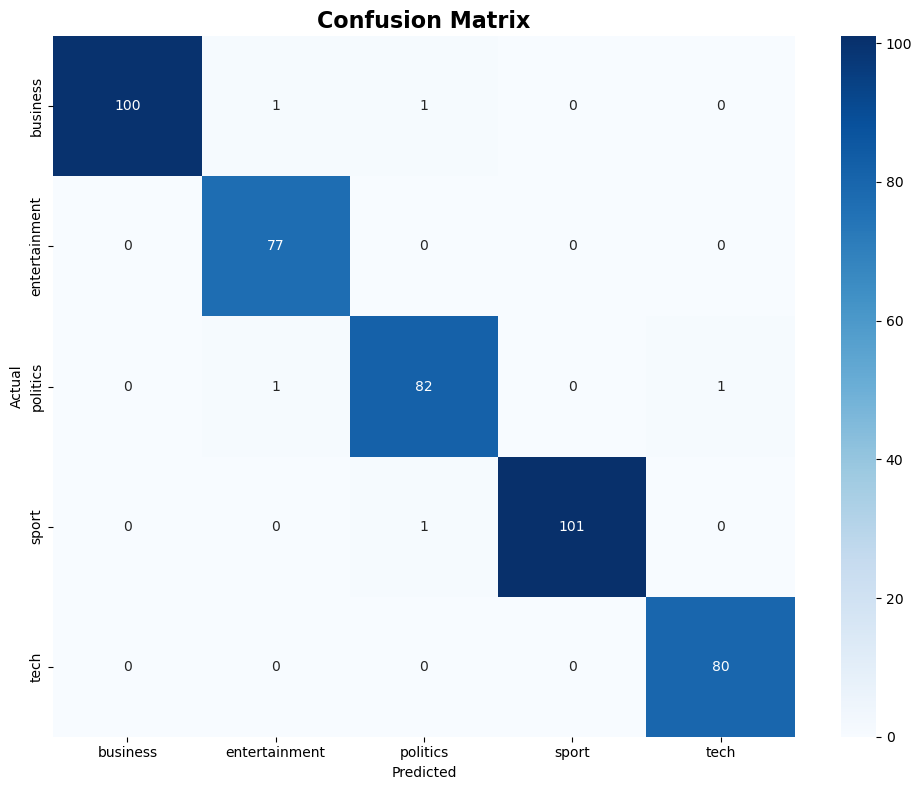

In [15]:
cm = confusion_matrix(y_test, y_test_pred)
classes = sorted(y.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### ROC Curves

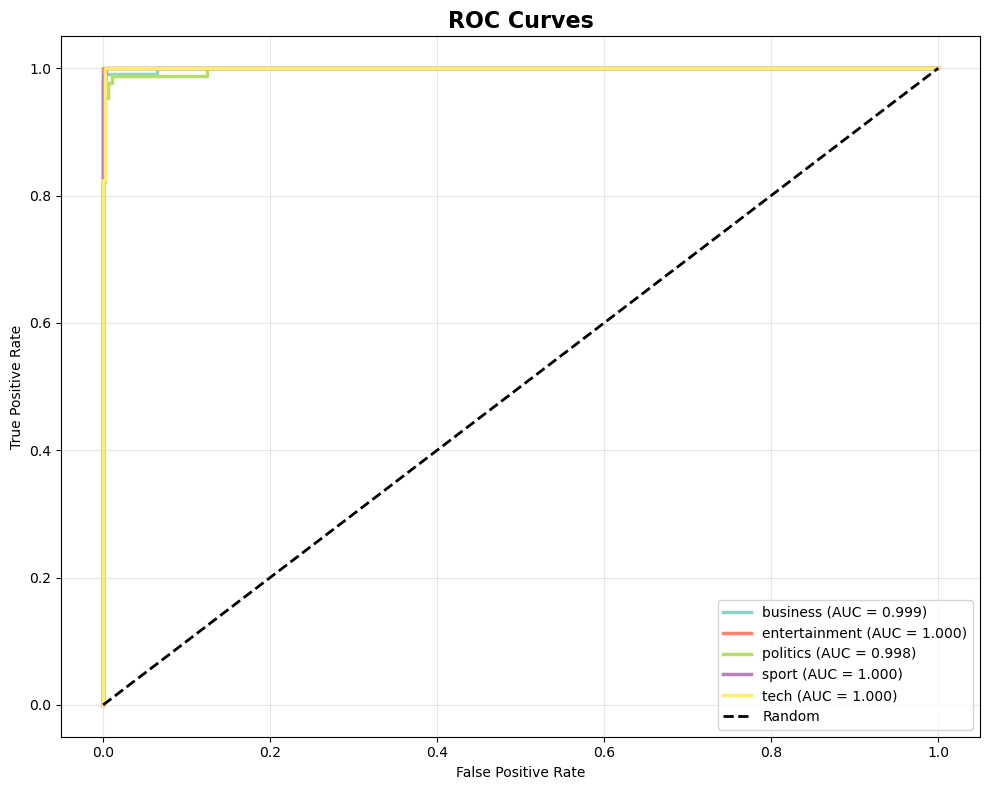


Average AUC: 0.9993


In [17]:
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'{classes[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage AUC: {np.mean(list(roc_auc.values())):.4f}")

### Precision-Recall Curve

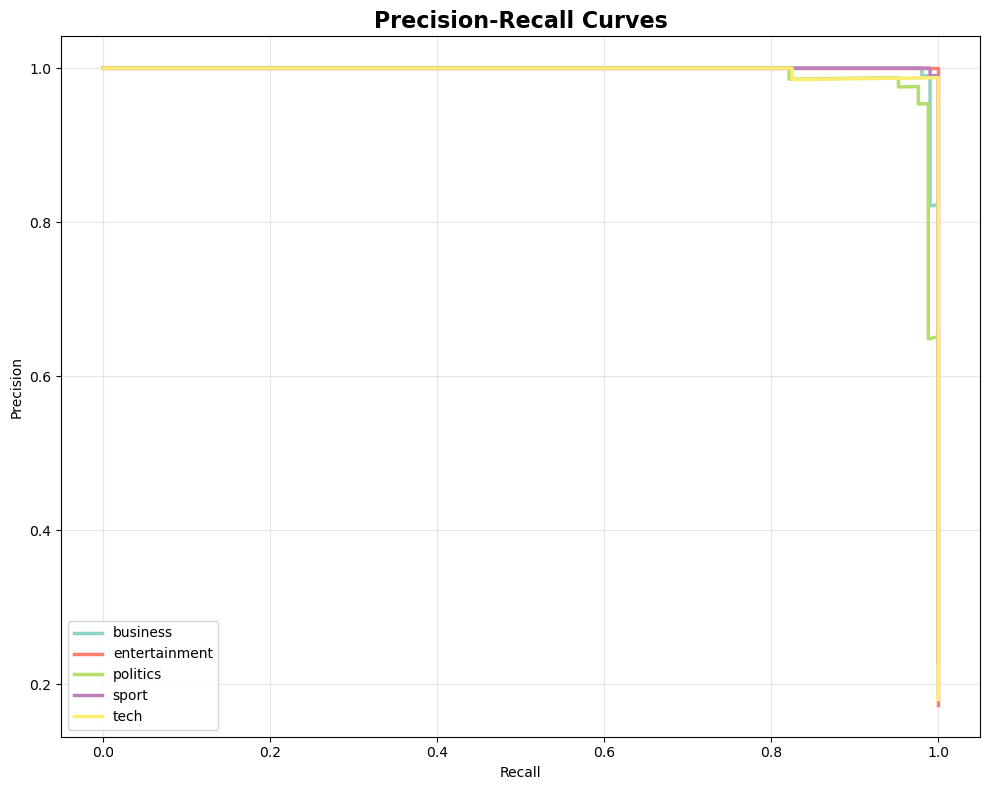

In [19]:
plt.figure(figsize=(10, 8))

for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, color=color, lw=2.5, label=classes[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontsize=16, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Overfitting and Underfitting analysis

In [23]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

gap = train_acc - test_acc

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Generalization Gap: {gap:.4f}")

if gap < 0.05:
    print("✓ Good fit (no overfitting)")
elif gap < 0.10:
    print("- Slight overfitting")
else:
    print("✗ Overfitting detected")

Training Accuracy: 0.9994
Testing Accuracy:  0.9888
Generalization Gap: 0.0107
✓ Good fit (no overfitting)


### Train VS Test Comparison

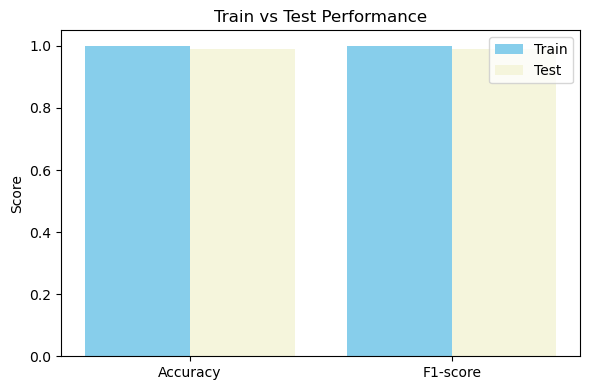

In [55]:
metrics = ['Accuracy', 'F1-score']

train_vals = [
    accuracy_score(y_train, y_train_pred),
    f1_score(y_train, y_train_pred, average='weighted')
]

test_vals = [
    accuracy_score(y_test, y_test_pred),
    f1_score(y_test, y_test_pred, average='weighted')
]

x = np.arange(len(metrics))

plt.figure(figsize=(6, 4))

plt.bar(x - 0.2, train_vals, width=0.4, label='Train', color='skyblue')
plt.bar(x + 0.2, test_vals, width=0.4, label='Test', color='beige')

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Train vs Test Performance')
plt.legend()

plt.tight_layout()
plt.show()


### Prediction on Sample Sentences

In [65]:
custom_samples = [
    ("The government announced new policies to improve the economy", "politics"),
    ("The football team won the match after scoring in the final minutes", "sport"),
    ("Technology companies are investing heavily in artificial intelligence", "tech"),
    ("Stock markets declined due to rising inflation concerns", "business"),
    ("The latest smartphone comes with a faster processor and better camera", "tech")
]

# Separate text and actual labels
custom_texts = [text for text, _ in custom_samples]
actual_labels = [label for _, label in custom_samples]

# Transform text using trained TF-IDF vectorizer
X_custom = tfidf.transform(custom_texts)

# Predict
predicted_labels = svm_model.predict(X_custom)
predicted_probas = svm_model.predict_proba(X_custom)

print("\nCUSTOM SAMPLE PREDICTIONS")
print("-" * 40)

for text, actual, predicted, proba in zip(
    custom_texts, actual_labels, predicted_labels, predicted_probas
):
    confidence = np.max(proba) * 100
    result = "CORRECT" if actual == predicted else "WRONG"

    print(f"\nSentence: {text}")
    print(f"Actual Label:    {actual}")
    print(f"Predicted Label: {predicted}")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Result: {result}")



CUSTOM SAMPLE PREDICTIONS
----------------------------------------

Sentence: The government announced new policies to improve the economy
Actual Label:    politics
Predicted Label: business
Confidence: 66.1%
Result: WRONG

Sentence: The football team won the match after scoring in the final minutes
Actual Label:    sport
Predicted Label: sport
Confidence: 99.2%
Result: CORRECT

Sentence: Technology companies are investing heavily in artificial intelligence
Actual Label:    tech
Predicted Label: business
Confidence: 38.7%
Result: WRONG

Sentence: Stock markets declined due to rising inflation concerns
Actual Label:    business
Predicted Label: business
Confidence: 54.5%
Result: CORRECT

Sentence: The latest smartphone comes with a faster processor and better camera
Actual Label:    tech
Predicted Label: tech
Confidence: 42.3%
Result: CORRECT
